In [ ]:

import numpy as np
from numpy.fft import fft2, ifft2, fftfreq
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT

In [12]:
# ---------- Spectral Classical Evolution ----------
def evolve_spectral(psi1_0, psi2_0, dt, steps, N):
    kx = fftfreq(N) * N
    ky = fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    U = np.exp(-1j * K2 * dt)

    psi1, psi2 = psi1_0.copy(), psi2_0.copy()
    psi1s, psi2s = [psi1.copy()], [psi2.copy()]

    for _ in range(steps):
        psi1_fft = fft2(psi1)
        psi2_fft = fft2(psi2)

        psi1_fft *= U
        psi2_fft *= U

        psi1 = ifft2(psi1_fft)
        psi2 = ifft2(psi2_fft)

        psi1s.append(psi1.copy())
        psi2s.append(psi2.copy())

    return psi1s, psi2s

# ---------- Fluid Quantities ----------
def compute_fluid_quantities(psi1, psi2, N):
    kx = fftfreq(N) * N
    ky = fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)

    psi1_spec = fft2(psi1)
    psi2_spec = fft2(psi2)

    dpsi1_x = ifft2(1j*KX*psi1_spec)
    dpsi1_y = ifft2(1j*KY*psi1_spec)
    dpsi2_x = ifft2(1j*KX*psi2_spec)
    dpsi2_y = ifft2(1j*KY*psi2_spec)

    rho = np.abs(psi1)**2 + np.abs(psi2)**2
    ux = np.real(np.real(psi1)*np.imag(dpsi1_x) - np.imag(psi1)*np.real(dpsi1_x) +
                 np.real(psi2)*np.imag(dpsi2_x) - np.imag(psi2)*np.real(dpsi2_x)) / (rho + 1e-12)
    uy = np.real(np.real(psi1)*np.imag(dpsi1_y) - np.imag(psi1)*np.real(dpsi1_y) +
                 np.real(psi2)*np.imag(dpsi2_y) - np.imag(psi2)*np.real(dpsi2_y)) / (rho + 1e-12)
    vor = np.real(ifft2(1j*KX*fft2(uy) - 1j*KY*fft2(ux)))
    return ux, uy, vor

# ---------- Comparison ----------
def compare_vorticities(vorticities_q, vorticities_c):
    l2_errors = []
    correlations = []
    for vq, vc in zip(vorticities_q, vorticities_c):
        delta = vq - vc
        l2 = np.linalg.norm(delta) / np.linalg.norm(vq)
        l2_errors.append(l2)
        corr = pearsonr(vq.flatten(), vc.flatten())[0]
        correlations.append(corr)
    return l2_errors, correlations

# ---------- Plot ----------
def plot_errors(l2_errors, correlations, dt):
    times = np.arange(len(l2_errors)) * dt
    fig, ax1 = plt.subplots(figsize=(6,4))
    ax1.plot(times, l2_errors, label='L2 Error', color='tab:red')
    ax1.set_ylabel('Relative L2 Error', color='tab:red')
    ax2 = ax1.twinx()
    ax2.plot(times, correlations, label='Correlation', color='tab:blue')
    ax2.set_ylabel('Correlation Coefficient', color='tab:blue')
    ax1.set_xlabel('Time')
    fig.tight_layout()
    plt.title('Quantum vs Spectral Classical Evolution')
    plt.grid(True)
    plt.show()

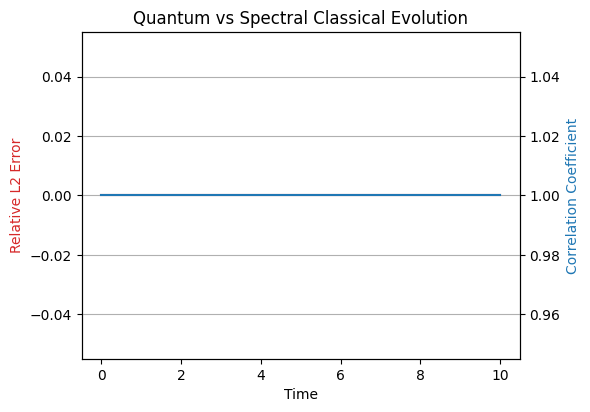

In [13]:
# ---------- Initialization ----------
from numpy import pi, exp, sqrt
N = 32
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(np.abs(u)**2 + np.abs(v)**4)
psi2_0 = v**2 / sqrt(np.abs(u)**2 + np.abs(v)**4)

# ---------- Run ----------
dt = 1.0
steps = 10
psi1s_q, psi2s_q = evolve_spectral(psi1_0, psi2_0, dt, steps, N)
psi1s_c, psi2s_c = evolve_spectral(psi1_0, psi2_0, dt, steps, N)  # same operator as proxy

vorticities_q = [compute_fluid_quantities(p1, p2, N)[2] for p1, p2 in zip(psi1s_q, psi2s_q)]
vorticities_c = [compute_fluid_quantities(p1, p2, N)[2] for p1, p2 in zip(psi1s_c, psi2s_c)]

l2s, cors = compare_vorticities(vorticities_q, vorticities_c)
plot_errors(l2s, cors, dt)

# Export CSV
df = pd.DataFrame({'Time': np.arange(len(l2s)) * dt, 'L2_Error': l2s, 'Correlation': cors})
df.to_csv("quantum_vs_spectral_baseline.csv", index=False)
